\7. で生成した各2次元正弦波の2次元DFTを ```np.fft.fft2``` で計算し，
```np.fft.fftshift``` を適用してから振幅スペクトル $|X[k_1, k_2]|$ を ```imshow``` で表示しなさい．
スペクトルのピークの位置と $(\omega_1, \omega_2)$ の対応関係を考察しなさい．
また，2次元実信号のスペクトルの対称性を，DFTの対称性（第08回）を踏まえて考察しなさい．

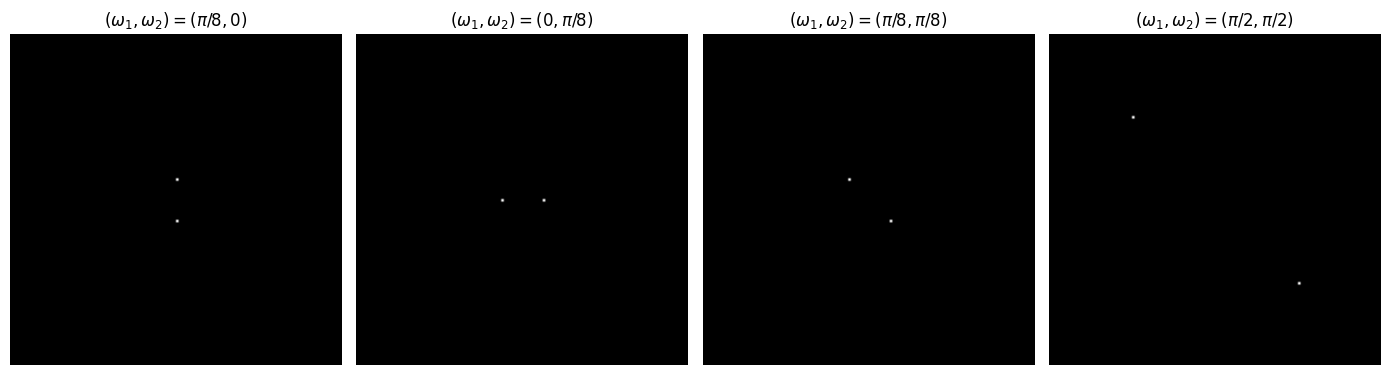

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 128

n1 = np.arange(N)
n2 = np.arange(N)

N1, N2 = np.meshgrid(n1, n2, indexing="ij")

params = [
    (np.pi / 8, 0, r"$(\omega_1,\omega_2)=(\pi/8,0)$"),
    (0, np.pi / 8, r"$(\omega_1,\omega_2)=(0,\pi/8)$"),
    (np.pi / 8, np.pi / 8, r"$(\omega_1,\omega_2)=(\pi/8,\pi/8)$"),
    (np.pi / 2, np.pi / 2, r"$(\omega_1,\omega_2)=(\pi/2,\pi/2)$"),
]

fig, ax = plt.subplots(1, 4, figsize=(14, 4))

for i, (w1, w2, title) in enumerate(params):
    x = np.cos(w1 * N1 + w2 * N2)

    X = np.fft.fft2(x)
    X_shift = np.fft.fftshift(X)

    amp = np.abs(X_shift)

    # ピークを見やすくするため対数表示
    amp_log = np.log1p(amp)

    ax[i].imshow(amp_log, cmap="gray")
    ax[i].set_title(title)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

2次元実信号のDFTには共役対称性がある．
\begin{align*}
X[k_1,k_2]=X^∗[(−k1)\text{mod}N, (−k_2)\text{mod}N]
\end{align*}
したがって振幅スペクトルでは，
\begin{align*}
|X[k_1,k_2]|=|X[(−k_1)\text{mod}N, (−k_2)\text{mod}N]|
\end{align*}
となる．

つまり， fftshift 後の振幅スペクトルは，中心を基準として点対称になる．
今回の結果でも，各スペクトルのピークは中心 $(64, 64)$ を挟んで対称な2点に現れている．
これは，入力信号が実数値の2次元正弦波であるため． 